# 周杰伦歌词生成

In [1]:
# # 从jupyter服务器下载数据集
# import os
# from IPython.display import FileLink, display

# file_path = 'data/jaychou_lyrics.txt.zip'

# if os.path.exists(file_path):
#     display(FileLink(file_path, result_html_prefix="点击下载: "))
# else:
#     print(f"错误：文件不存在于路径 {file_path}，请检查路径或先运行生成文件的代码。")

## 1、读取数据集

In [2]:
import tensorflow as tf
from tensorflow import keras
import random
import zipfile
import numpy as np
import math
import matplotlib.pyplot as plt
from IPython.display import clear_output
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation
from tensorflow.keras.layers import Embedding, LayerNormalization
from tensorflow.keras.layers import GRU

# 配置matplotlib中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

In [3]:
with zipfile.ZipFile('data/jaychou_lyrics.txt.zip') as zin:
    with zin.open('jaychou_lyrics.txt') as f:
        corpus_chars = f.read().decode('utf-8')

In [4]:
print(corpus_chars[:40])

想要有直升机
想要和你飞到宇宙去
想要和你融化在一起
融化在宇宙里
我每天每天每


## 2、建立字符索引

In [5]:
# 使用set()函数将数据集中重复的字符删掉，然后将其放入列表
idx_to_char = list(set(corpus_chars))
len(idx_to_char)

2583

In [6]:
# 将字符映射到索引
char_to_idx = {char: i for i, char in enumerate(idx_to_char)}

In [7]:
vocab_size = len(char_to_idx)
vocab_size

2583

In [8]:
# 将字符转化为索引
corpus_indices = [char_to_idx[char] for char in corpus_chars]
len(corpus_indices)

63282

corpus_indices中是原始数据集corpus_char中所有字符的索引值。我们可以打印前20个字符机器对应的索引：

In [9]:
sample = corpus_indices[1000:1020]
print('indices:', sample)
print('chars:', ''.join([idx_to_char[idx] for idx in sample]))

indices: [172, 1229, 1232, 2094, 1020, 1776, 172, 667, 2000, 667, 2000, 824, 1849, 2203, 850, 172, 1624, 1020, 517, 2463]
chars: 
随风跟著我
一口一口吃掉忧愁
载著你 


## 3、时序数据采样

与其他实验数据不同的是，时序数据的一个样本通常包含连续的字符。假设时间步数为5，样本序列为5个字符，即“想”“要”“有”“直”“升”。该样本的标签序列为这些字符分别在训练集中的下一个字符，即“要”“有”“直”“升”“机”。我们有两种方式对时序数据进行采样，分别是随机采样和相邻采样。设批量大小batch_size指每个小批量的样本数，num steps为每个样本所包含的时间步数：


### 3.1随机采样

在随机采样中，每个样本是原始序列上任意截取的一段序列。相邻的两个随机小批量在原始序列上的位置不一定相邻。因此，我们无法用一个小批量最终时间步的隐藏状态来初始化下一个小批量的隐藏状态。在训练模型时，每次随机采样前都需要重新初始化隐藏状态。


### 3.2相邻采样

除对原始序列做随机采样之外，我们还可以令相邻的两个随机小批量在原始序列上的位置相邻。这时候，我们就可以用一个小批量最终时间步的隐藏状态来初始化下一个小批量的隐藏状态，从而使下一个小批量的输出也取决于当前小批量的输入，并如此循环下去。这对实现循环神经网络造成了两方面影响：一方面，在训练模型时，我们只需在每一个迭代周期开始时初始化隐藏状态；另一方面，当多个相邻小批量通过传递隐藏状态串联起来时，模型参数的梯度计算将依赖所有串联起来的小批量序列。同一迭代周期中，随着迭代次数的增加，梯度的计算开销会越来越大。为了使模型参数的梯度计算只依赖一次迭代读取的小批量序列，我们可以在每次读取小批量前将隐藏状态从计算图中分离出来。


In [10]:
def data_iter_consecutive(corpus_indices, batch_size, num_steps, ctx=None):
    corpus_indices = np.array(corpus_indices)
    data_len = len(corpus_indices)
    batch_len = data_len // batch_size
    # 去掉尾部零头
    indices = corpus_indices[0: batch_size*batch_len].reshape((batch_size, batch_len))
    epoch_size = (batch_len - 1) // num_steps
    
    for i in range(epoch_size):
        i = i * num_steps
        X = indices[:, i: i+num_steps]
        Y = indices[:, i+1: i+num_steps+1]
        yield X, Y

In [11]:
# 用法示例
my_seq = list(range(30))
for  X, Y in data_iter_consecutive(my_seq, batch_size=2, num_steps=6):
    print('X:', X, '\nY:', Y, '\n')

X: [[ 0  1  2  3  4  5]
 [15 16 17 18 19 20]] 
Y: [[ 1  2  3  4  5  6]
 [16 17 18 19 20 21]] 

X: [[ 6  7  8  9 10 11]
 [21 22 23 24 25 26]] 
Y: [[ 7  8  9 10 11 12]
 [22 23 24 25 26 27]] 



## 4、定义模型

### 4.1 定义循环神经网络层

Keras的RNN模块提供了循环神经网络的实现。下面构造一个含多层隐藏层、隐藏单元个数为512的多层GRU循环神经网络，并引入<b>残差连接</b>和<b>层归一化</b>。相比原始的单层LSTM，多层堆叠的GRU网络具有更强的表达能力，能够捕捉更深层次的时序特征。残差连接使梯度能够更顺畅地回传，缓解深层网络的梯度退化问题；层归一化稳定每层的输出分布，加速训练收敛。GRU相比LSTM参数更少、训练更快，同时通过多层堆叠可以弥补单层表达能力不足的问题。
返回的隐藏状态指的是隐藏层在最后时间步的隐藏状态：当隐藏层有多层时，每一层的隐藏状态都会记录在该变量中。

In [12]:
# 超参数设置
num_hiddens = 512          
batch_size = 128          
num_steps = 50             
embed_dim = 512            
dropout_rate = 0.2         


# batch_shape中时间维设为None，允许训练时输入num_steps长度、预测时输入1个时间步
inputs = keras.Input(batch_shape=(batch_size, None))
x = Embedding(output_dim=embed_dim, input_dim=vocab_size)(inputs)

# 第一层GRU + 残差连接 + 层归一化
residual = x
gru1 = GRU(units=num_hiddens, return_sequences=True, stateful=True,
           dropout=dropout_rate, name='gru_1')(x)
gru1 = LayerNormalization(name='ln_1')(gru1)
x = gru1 + residual  # 残差连接

# 第二层GRU + 残差连接 + 层归一化
residual = x
gru2 = GRU(units=num_hiddens, return_sequences=True, stateful=True,
           dropout=dropout_rate, name='gru_2')(x)
gru2 = LayerNormalization(name='ln_2')(gru2)
x = gru2 + residual  # 残差连接

# 第三层GRU + 残差连接 + 层归一化
residual = x
gru3 = GRU(units=num_hiddens, return_sequences=True, stateful=True,
           dropout=dropout_rate, name='gru_3')(x)
gru3 = LayerNormalization(name='ln_3')(gru3)
x = gru3 + residual  # 残差连接

# 输出层：映射到词典大小的概率分布
outputs = Dense(units=vocab_size, activation='softmax')(x)
model = keras.Model(inputs=inputs, outputs=outputs)

model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(128, None)]        0           []                               
                                                                                                  
 embedding (Embedding)          (128, None, 512)     1322496     ['input_1[0][0]']                
                                                                                                  
 gru_1 (GRU)                    (128, None, 512)     1575936     ['embedding[0][0]']              
                                                                                                  
 ln_1 (LayerNormalization)      (128, None, 512)     1024        ['gru_1[0][0]']                  
                                                                                              

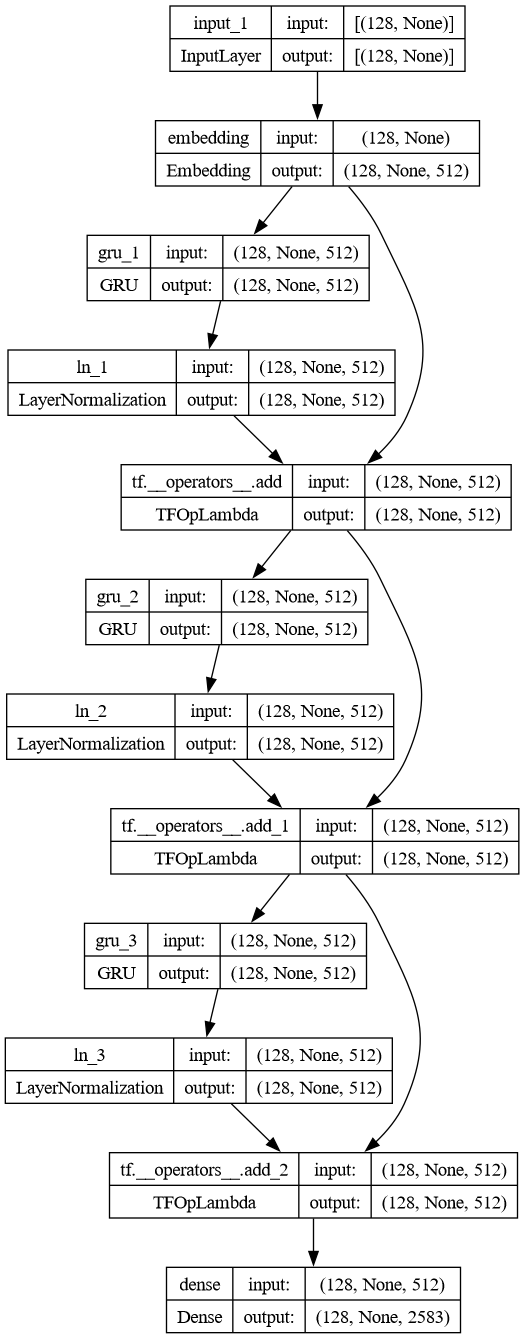

In [13]:
from tensorflow.keras.utils import plot_model
plot_model(model=model, show_shapes=True, show_layer_names=True)

将经过采样后的样本直接输入此网络中时，它经过的处理操作依次为：输入形状为(批量大小，时间步数)利用Embedding编码得到(批量大小，时间步数，embedding维度=512)，依次经过3层GRU（每层带有残差连接和层归一化），每层得到(批量大小，时间步数，隐藏单元个数=512)，最终经过Dense层，得到(批量大小，时间步数，词典大小)。残差连接使每层GRU的输出与输入相加，缓解深层网络的梯度退化问题；层归一化稳定每层的输出分布，加速训练收敛。


In [14]:
def sample(preds, temperature=0.8, top_p=0.9):
    """Top-P (Nucleus) 采样：从概率累积和达到p的最小字符集合中采样
    
    相比原始的纯温度采样，Top-P采样只从高概率候选中采样，
    有效过滤掉概率极低的不合理字符，生成结果更连贯。
    
    参数:
        preds: 模型输出的概率分布
        temperature: 温度参数，越低越保守，越高越随机
        top_p: 累积概率阈值，只从概率累积和达到top_p的候选中采样
    """
    preds = np.asarray(preds).astype('float64')
    preds = np.log(preds + 1e-8) / temperature
    exp_preds = np.exp(preds)
    preds = exp_preds / np.sum(exp_preds)
    
    # 按概率降序排列
    sorted_indices = np.argsort(preds)[::-1]
    sorted_preds = preds[sorted_indices]
    cumulative_probs = np.cumsum(sorted_preds)
    
    # 找到累积概率超过top_p的截断位置，只保留高概率候选
    cutoff_index = np.searchsorted(cumulative_probs, top_p) + 1
    selected_indices = sorted_indices[:cutoff_index]
    selected_preds = preds[selected_indices]
    selected_preds = selected_preds / np.sum(selected_preds)  # 重新归一化
    
    return np.random.choice(selected_indices, p=selected_preds)

In [15]:
def reset_model_states():
    """重置模型中所有有状态RNN层的隐藏状态（兼容Functional API）"""
    for layer in model.layers:
        if hasattr(layer, 'reset_states'):
            layer.reset_states()

def predict_rnn_keras(prefix, num_chars):
    # 使用自定义函数初始化隐藏状态，兼容Functional API
    reset_model_states()
    output = [char_to_idx[prefix[0]]]
    
    for t in range(num_chars + len(prefix) - 1):
        X = (np.array([output[-1]]).repeat(batch_size)).reshape((batch_size, 1))
        Y = model(X)   # 批量大小，时间步数，词典大小
        
        if t < len(prefix) - 1:
            output.append(char_to_idx[prefix[t+1]])
        else:
            output.append(sample(np.array(Y[0,0,:])))
    
    return ''.join([idx_to_char[i] for i in output])

In [16]:
predict_rnn_keras('分开', 10)

'分开饭狈悉陋步灰清糕奪违'

## 5、裁剪梯度

下面代码用于描述clipnorm含义，实际未使用
#计算裁剪后的梯度示意代码，本例并不使用该函数!!!def grad_clipping(grads,theta): norm = np.array([0])fori in range(len(grads)): norm+=tf.math.reduce_sum(grads[i]**2) norm = np.sqrt(norm).item() if norm<=theta: return grads new_gradient=[] for grad in grads: new_gradient.append(grad*theta/norm)returnnew_gradient


## 6、定义模型训练函数

初始化优化器

In [17]:
# 使用余弦退火学习率调度，训练前期学习率较高快速收敛，后期逐渐降低精细调优
lr_schedule = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=5e-4,
    decay_steps=1500,
    alpha=1e-5  # 最低学习率
)

# clipnorm从0.1放宽至1.0，避免梯度信号被过度裁剪
opt = keras.optimizers.Adam(learning_rate=lr_schedule, clipnorm=1.0)

model.compile(loss='sparse_categorical_crossentropy',
              optimizer=opt,
              metrics=['accuracy'])

## 7、训练

### 定义梯度下降函数

定义训练函数num_epochs:训练次数； batch_size:批次大小； pred_period:间隔多少次
展示一次结果； pred_len:要求预测的字符长度。


In [18]:
def train_and_predict_rnn_keras(num_epochs, batch_size, pred_period, pred_len, prefixes):
    all_losses = []       # 记录每个epoch的平均损失
    all_perplexities = [] # 记录每个epoch的困惑度
    
    for epoch in range(num_epochs):
        l_sum, n = 0.0, 0
        reset_model_states()
        data_iter = data_iter_consecutive(corpus_indices, batch_size, num_steps)

        for X, Y in data_iter:
            y_pred = model.train_on_batch(X, Y)
            loss = y_pred[0]
            l_sum += loss
            n += 1
        
        avg_loss = l_sum / n
        ppl = math.exp(avg_loss)
        all_losses.append(avg_loss)
        all_perplexities.append(ppl)

        if (epoch+1) % pred_period == 0:
            clear_output(wait=True)
            print(f'epoch {epoch+1}/{num_epochs}, 平均Loss: {avg_loss:.4f}, 困惑度: {ppl:.3f}')
            
            # # ===== 训练进度可视化 =====
            # fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
            
            # ax1.plot(range(1, epoch+2), all_losses, 'b-', linewidth=1.5)
            # ax1.set_title('训练损失曲线', fontsize=14)
            # ax1.set_xlabel('Epoch', fontsize=12)
            # ax1.set_ylabel('Loss', fontsize=12)
            # ax1.grid(True, alpha=0.3)
            
            # ax2.plot(range(1, epoch+2), all_perplexities, 'r-', linewidth=1.5)
            # ax2.set_title('困惑度曲线', fontsize=14)
            # ax2.set_xlabel('Epoch', fontsize=12)
            # ax2.set_ylabel('Perplexity', fontsize=12)
            # ax2.grid(True, alpha=0.3)
            
            # plt.tight_layout()
            # plt.show()
            
            # 展示生成结果
            for prefix in prefixes:
                print('>>', predict_rnn_keras(prefix, pred_len))
    
    return all_losses, all_perplexities

# 训练参数
num_epochs = 1500
losses, ppls = train_and_predict_rnn_keras(
    num_epochs, batch_size, pred_period=100, pred_len=50, prefixes=['如果有人在灯塔', '如果感情会挣扎']
)

epoch 1500/1500, 平均Loss: 0.0522, 困惑度: 1.054
>> 如果有人在灯塔上
一城市脚 想我的秋天
飘落后才发现
这幸福的碎片
要我怎么捡
冷咖啡离开了杯垫
我忍住的情绪在很
>> 如果感情会挣扎
千年的恩怨
一笔勾销
千年恩怨
一笔勾销
生命潦草
我在弯腰
生命潦草
我在弯腰
历史轮回
转身忘
